# Training model without any preprocessing or feature engineering

## Import Libraries

In [31]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import re
from bs4 import BeautifulSoup
import string
import joblib
import json

## Load Dataset

In [32]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH  = os.path.join("../data", "quora_question_pair_final.csv")
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR,  exist_ok=True)

RANDOM_STATE = 42
print(f"   Data Path → {DATA_PATH}")
print(f"   Model output → {MODEL_DIR}")

   Data Path → ../data\quora_question_pair_final.csv
   Model output → ../models


In [33]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(404287, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.916659,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,0.699993,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.399996,0.0,1.0,4.0,12.0,0.169492,54,53,66,66
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,...,0.000000,0.0,0.0,1.0,11.5,0.040000,36,39,37,36
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,...,0.571420,0.0,1.0,6.0,10.0,0.153846,46,55,47,67


In [34]:
df = df.sample(200000)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 248449 to 335090
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    200000 non-null  int64  
 1   qid1                  200000 non-null  int64  
 2   qid2                  200000 non-null  int64  
 3   question1             199992 non-null  object 
 4   question2             199997 non-null  object 
 5   is_duplicate          200000 non-null  int64  
 6   q1_len                200000 non-null  int64  
 7   q2_len                200000 non-null  int64  
 8   q1_num_words          200000 non-null  int64  
 9   q2_num_words          200000 non-null  int64  
 10  word_common           200000 non-null  int64  
 11  word_total            200000 non-null  int64  
 12  word_share            200000 non-null  float64
 13  cwc_min               200000 non-null  float64
 14  cwc_max               200000 non-null  float64
 15  

In [36]:
df.isnull().sum()

id                      0
qid1                    0
qid2                    0
question1               8
question2               3
is_duplicate            0
q1_len                  0
q2_len                  0
q1_num_words            0
q2_num_words            0
word_common             0
word_total              0
word_share              0
cwc_min                 0
cwc_max                 0
csc_min                 0
csc_max                 0
ctc_min                 0
ctc_max                 0
last_word_eq            0
first_word_eq           0
abs_len_diff            0
mean_len                0
longest_substr_ratio    0
fuzz_ratio              0
fuzz_partial_ratio      0
token_sort_ratio        0
token_set_ratio         0
dtype: int64

In [37]:
df.dropna(inplace=True)

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
def preprocess(q):
    q = str(q).lower().strip()

    # Replace certain special character with their string equivalents
    q = q.replace('%','percent')
    q = q.replace('$','dollar')
    q = q.replace('₹','rupee')
    q = q.replace('€','euro')
    q = q.replace('@','at')

    # The pattern '[math]' appears around 900 times in the whole dataset
    q = q.replace('[math]','')

    # Replcing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # website from which contraction words have been taken
    # https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python/19794953#19794953
    contractions = { 
    "ain't": "am not / are not / is not / has not / have not",
    "aren't": "are not / am not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he had / he would",
    "he'd've": "he would have",
    "he'll": "he shall / he will",
    "he'll've": "he shall have / he will have",
    "he's": "he has / he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how has / how is / how does",
    "I'd": "I had / I would",
    "I'd've": "I would have",
    "I'll": "I shall / I will",
    "I'll've": "I shall have / I will have",
    "I'm": "I am",
    "I've": "I have",
    "isn't": "is not",
    "it'd": "it had / it would",
    "it'd've": "it would have",
    "it'll": "it shall / it will",
    "it'll've": "it shall have / it will have",
    "it's": "it has / it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she had / she would",
    "she'd've": "she would have",
    "she'll": "she shall / she will",
    "she'll've": "she shall have / she will have",
    "she's": "she has / she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as / so is",
    "that'd": "that would / that had",
    "that'd've": "that would have",
    "that's": "that has / that is",
    "there'd": "there had / there would",
    "there'd've": "there would have",
    "there's": "there has / there is",
    "they'd": "they had / they would",
    "they'd've": "they would have",
    "they'll": "they shall / they will",
    "they'll've": "they shall have / they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we had / we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what shall / what will",
    "what'll've": "what shall have / what will have",
    "what're": "what are",
    "what's": "what has / what is",
    "what've": "what have",
    "when's": "when has / when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where has / where is",
    "where've": "where have",
    "who'll": "who shall / who will",
    "who'll've": "who shall have / who will have",
    "who's": "who has / who is",
    "who've": "who have",
    "why's": "why has / why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you had / you would",
    "you'd've": "you would have",
    "you'll": "you shall / you will",
    "you'll've": "you shall have / you will have",
    "you're": "you are",
    "you've": "you have"
    }
    
    q_decontracted = []
    for word in q.split():
        if word in contractions:
            word = contractions[word]
        q_decontracted.append(word)
    
    q = ' '.join(q_decontracted)
    q = q.replace("'ve"," have")
    q = q.replace("n't"," not")
    q = q.replace("'re"," are")
    q = q.replace("'ll"," will")
    
    # Removing HTML Tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove Punctualtions
    
    pattern = re.compile('\W')
    q = re.sub(pattern,' ', q).strip()
        
    exclude = string.punctuation
    q = q.translate(str.maketrans('','',exclude))

    return q

<>:162: SyntaxWarning: invalid escape sequence '\W'
<>:162: SyntaxWarning: invalid escape sequence '\W'
C:\Users\DELL\AppData\Local\Temp\ipykernel_13956\2229890794.py:162: SyntaxWarning: invalid escape sequence '\W'
  pattern = re.compile('\W')


In [40]:
question1 = [text.split() for text in (df['question1'].apply(preprocess)).astype(str)]
question2 = [text.split() for text in df['question2'].apply(preprocess).astype(str)]
questions = question1 + question2

In [ ]:
w2v = Word2Vec(
    questions,
    vector_size=200,
    window=5,
    min_count=1
)

In [ ]:
w2v.build_vocab(questions)

In [ ]:
w2v.train(questions, total_examples=w2v.corpus_count, epochs=w2v.epochs)

(16052230, 22546485)

In [ ]:
len(w2v.wv.index_to_key)

63550

In [ ]:
def document_vector(doc):
    doc = [word for word in doc.split() if word in w2v.wv.index_to_key]
    return np.mean(w2v.wv[doc], axis=0)

In [46]:
X = []

for q1, q2 in tqdm(zip(df['question1'].fillna(''),
                       df['question2'].fillna('')),
                   total=len(df)):
    
    q1_vec = document_vector(q1)
    q2_vec = document_vector(q2)

    X.append(np.concatenate([q1_vec, q2_vec]))

100%|██████████| 199989/199989 [10:26<00:00, 319.37it/s]


In [47]:
X = np.array(X)
y = df['is_duplicate']

In [48]:
features = df[['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words',
               'word_common', 'word_total', 'word_share',
               'cwc_min', 'cwc_max', 'csc_min', 'csc_max',
               'ctc_min', 'ctc_max', 'last_word_eq', 'first_word_eq',
               'abs_len_diff', 'mean_len', 'longest_substr_ratio',
               'fuzz_ratio', 'fuzz_partial_ratio',
               'token_sort_ratio', 'token_set_ratio']].values

X = np.hstack((X, features))

In [49]:
X.shape

(199989, 422)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [53]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8185909295464773

In [61]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test, y_pred)

0.8166908345417271

In [62]:
confusion_matrix(y_test, y_pred)

array([[21633,  3608],
       [ 3724, 11033]])

## 5. Evaluation & Metrics

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score, average_precision_score
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import joblib
import json
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
ap  = average_precision_score(y_test, y_pred_prob)

print("═" * 45)
print("  FINAL TEST SET RESULTS")
print("═" * 45)
print(f"  Accuracy          : {acc:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  ROC-AUC           : {auc:.4f}")
print(f"  Avg Precision     : {ap:.4f}")
print("═" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non Duplicate", "Duplicate"]))

═════════════════════════════════════════════
  FINAL TEST SET RESULTS
═════════════════════════════════════════════
  Accuracy          : 0.8186
  F1 Score          : 0.7504
  ROC-AUC           : 0.9040
  Avg Precision     : 0.8414
═════════════════════════════════════════════

Classification Report:
               precision    recall  f1-score   support

Non Duplicate       0.85      0.87      0.86     25241
    Duplicate       0.76      0.74      0.75     14757

     accuracy                           0.82     39998
    macro avg       0.81      0.80      0.80     39998
 weighted avg       0.82      0.82      0.82     39998



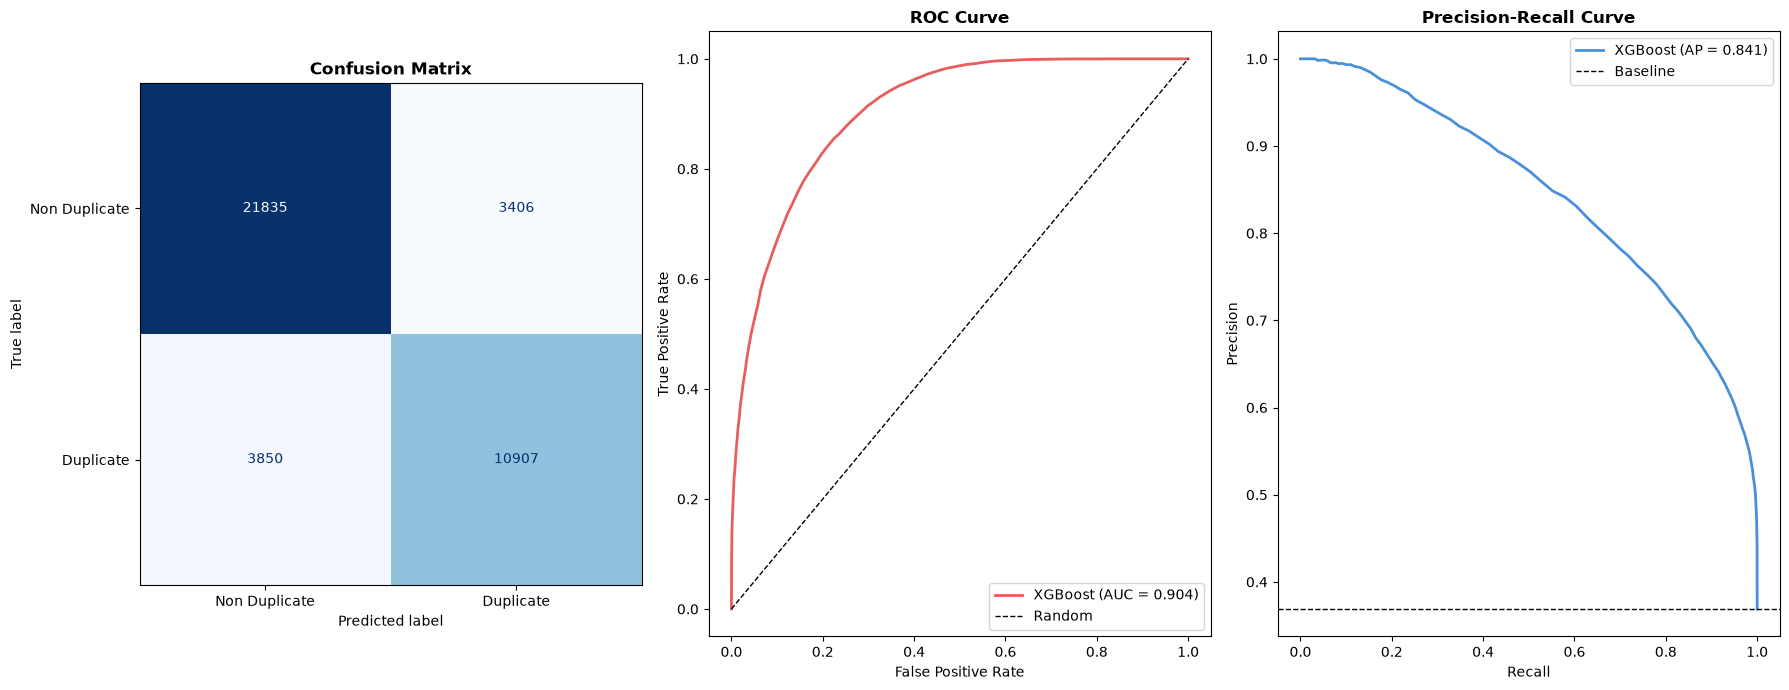

In [64]:
# ── Confusion Matrix + ROC + PR curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non Duplicate", "Duplicate"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#E85D5D", lw=2, label=f"XGBoost (AUC = {auc:.3f})")
axes[1].plot([0,1], [0,1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(rec, prec, color="#4A90D9", lw=2, label=f"XGBoost (AP = {ap:.3f})")
axes[2].axhline(y_test.mean(), color="k", linestyle="--", lw=1, label="Baseline")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve", fontweight="bold")
axes[2].legend()

plt.tight_layout()
# plt.savefig(f"{MODEL_DIR}/evaluation_curves.png", bbox_inches="tight")
plt.show()


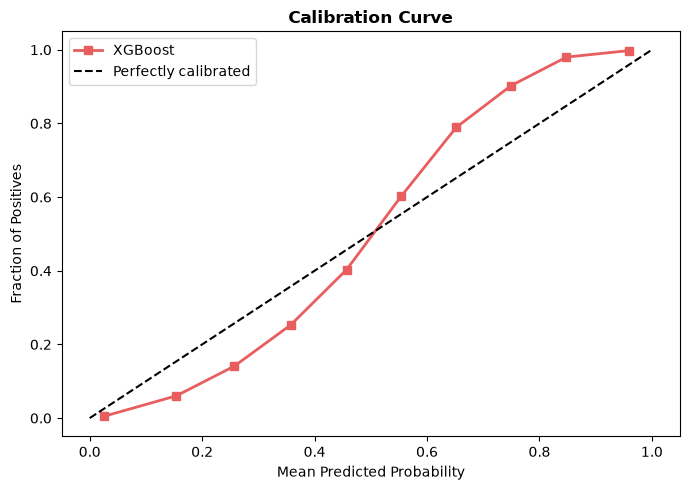

A well-calibrated model follows the diagonal line closely.


In [65]:
# ── Calibration curve (is the model's probability reliable?) ──
fig, ax = plt.subplots(figsize=(7, 5))
frac_pos, mean_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
ax.plot(mean_pred, frac_pos, "s-", color="#E85D5D", label="XGBoost", lw=2)
ax.plot([0,1], [0,1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve", fontweight="bold")
ax.legend()
plt.tight_layout()
# plt.savefig(f"{MODEL_DIR}/calibration_curve.png", bbox_inches="tight")
plt.show()
print("A well-calibrated model follows the diagonal line closely.")

## 6. Threshold Tuning

In [66]:
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for thr in thresholds:
    yp = (y_pred_prob >= thr).astype(int)
    results.append({
        "threshold": round(thr, 2),
        "accuracy" : accuracy_score(y_test, yp),
        "f1"       : f1_score(y_test, yp, zero_division=0),
        "precision": confusion_matrix(y_test, yp)[1,1] /
                     (confusion_matrix(y_test, yp)[1,1] + confusion_matrix(y_test, yp)[0,1] + 1e-9),
        "recall"   : confusion_matrix(y_test, yp)[1,1] /
                     (confusion_matrix(y_test, yp)[1,1] + confusion_matrix(y_test, yp)[1,0] + 1e-9),
    })

thr_df = pd.DataFrame(results)
best_thr = thr_df.loc[thr_df["f1"].idxmax(), "threshold"]
print(f"Best threshold by F1 : {best_thr}")
print(thr_df.to_string(index=False))

Best threshold by F1 : 0.45
 threshold  accuracy       f1  precision   recall
      0.10  0.618481 0.658506   0.491597 0.997018
      0.15  0.658433 0.681761   0.519434 0.991665
      0.20  0.688059 0.699718   0.542547 0.985092
      0.25  0.715486 0.716407   0.566552 0.974046
      0.30  0.742712 0.732750   0.594021 0.956021
      0.35  0.769838 0.748841   0.626753 0.929999
      0.40  0.792415 0.759243   0.663558 0.887172
      0.45  0.811616 0.764244   0.709893 0.827607
      0.50  0.818591 0.750396   0.762035 0.739107
      0.55  0.811116 0.710170   0.818391 0.627228
      0.60  0.789114 0.637936   0.870141 0.503558
      0.65  0.760963 0.546808   0.909779 0.390865
      0.70  0.730712 0.440787   0.942496 0.287660
      0.75  0.704335 0.338591   0.969260 0.205123
      0.80  0.682859 0.248652   0.987300 0.142238
      0.85  0.664433 0.166646   0.994811 0.090940
      0.90  0.652783 0.111452   0.997709 0.059023


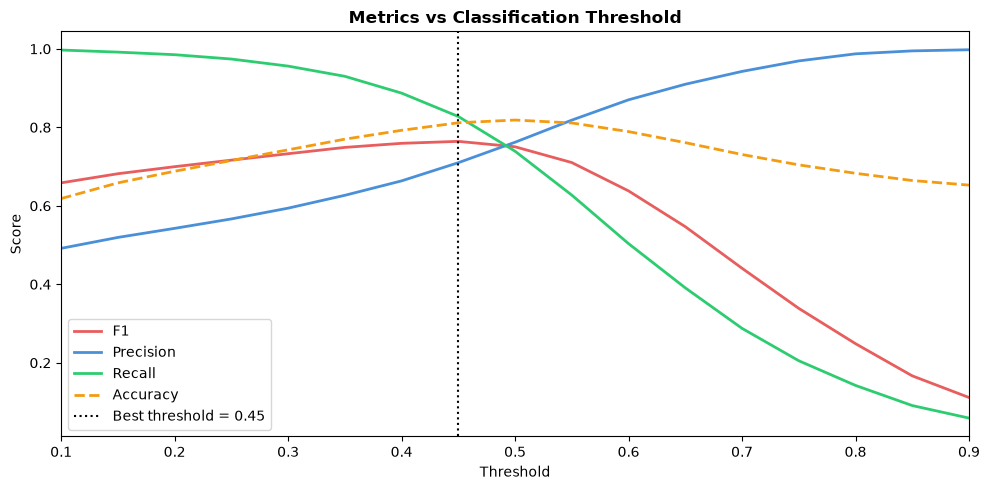


✅ Using threshold: 0.45


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df["threshold"], thr_df["f1"],        label="F1",        lw=2, color="#E85D5D")
ax.plot(thr_df["threshold"], thr_df["precision"],  label="Precision",  lw=2, color="#4A90D9")
ax.plot(thr_df["threshold"], thr_df["recall"],     label="Recall",     lw=2, color="#2ECC71")
ax.plot(thr_df["threshold"], thr_df["accuracy"],   label="Accuracy",   lw=2, color="#F39C12", linestyle="--")
ax.axvline(best_thr, color="black", linestyle=":", label=f"Best threshold = {best_thr}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Metrics vs Classification Threshold", fontweight="bold")
ax.legend(); ax.set_xlim(0.1, 0.9)
plt.tight_layout()
# plt.savefig(f"{MODEL_DIR}/threshold_tuning.png", bbox_inches="tight")
plt.show()

BEST_THRESHOLD = float(best_thr)
print(f"\n✅ Using threshold: {BEST_THRESHOLD}")

## 7. Save Model & Artifacts

In [ ]:
# Save XGBoost model and Word2Vec model
model_path_xgb = os.path.join(MODEL_DIR, "model.pkl")
model_path_w2v = os.path.join(MODEL_DIR, "w2v.pkl")
joblib.dump(xgb, model_path_xgb)
joblib.dump(w2v, model_path_w2v)
print(f"✅ Model saved       → {model_path_xgb}")
print(f"✅ Model saved       → {model_path_w2v}")

# Save metadata
y_pred_tuned = (y_pred_prob >= BEST_THRESHOLD).astype(int)

meta = {
    "model"            : "RandomForestClassifier",
    "best_threshold"   : BEST_THRESHOLD,
    "train_rows"       : int(len(X_train)),
    "test_rows"        : int(len(X_test)),
    "metrics": {
        "accuracy"     : round(accuracy_score(y_test, y_pred_tuned), 4),
        "f1_score"     : round(f1_score(y_test, y_pred_tuned, zero_division=0), 4),
        "roc_auc"      : round(roc_auc_score(y_test, y_pred_prob), 4),
        "avg_precision": round(average_precision_score(y_test, y_pred_prob), 4),
    }
}

meta_path = os.path.join(MODEL_DIR, "model_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
    
print(f"✅ Metadata saved    → {meta_path}")
print(f"\nFinal Metrics (threshold={BEST_THRESHOLD}):")
for k, v in meta["metrics"].items():
    print(f"  {k:<18}: {v}")


✅ Model saved       → ../models\model2.pkl
✅ Model saved       → ../models\cv.pkl
✅ Metadata saved    → ../models\model_meta.json

Final Metrics (threshold=0.45):
  accuracy          : 0.8086
  f1_score          : 0.7643
  roc_auc           : 0.904
  avg_precision     : 0.8414


In [1]:
def predict_duplicate(x, threshold: float = BEST_THRESHOLD) -> dict:
    
    prob = xgb.predict_proba(x)[0][1]
    will_rain = prob >= threshold

    if prob > 0.75:   confidence = "high (rain likely)"
    elif prob > 0.55: confidence = "medium"
    elif prob < 0.25: confidence = "high (no rain likely)"
    else:             confidence = "low (uncertain)"

    return {
        "duplicate": bool(will_rain),
        "probability"  : round(float(prob), 4),
        "confidence"   : confidence
    }

# ── Demo on 5 test samples ──
print("── Demo Predictions on Test Samples ──")
print(f"{'#':<4} {'Prob':>6} {'Predicted':>12} {'Actual':>10} {'Match':>6}")
print("─" * 45)
for i in range(5):
    sample = X_test[i]
    result = predict_duplicate(sample)
    actual = int(y_test[i])
    pred   = "Rain" if result["rain_tomorrow"] else "No Rain"
    act    = "Rain" if actual else "No Rain"
    match  = "✅" if pred == act else "❌"
    print(f"{i+1:<4} {result['probability']:>6.4f} {pred:>12} {act:>10} {match:>6}")


NameError: name 'BEST_THRESHOLD' is not defined